# 1 · Machine learning, the WeatherGenerator & the ERA5 data

Welcome to the downscaling hackathon! 🌍

## The challenge

We want to **downscale** atmospheric states from a coarse **1°** resolution (O96) to a
fine **0.25°** resolution (N320) using the **WeatherGenerator (WG)** model. WG is a large
foundation model for the Earth system. It is an **encoder–latent–decoder** model that we
normally use for **time advancement** — predicting the next 6-hourly atmospheric state
conditioned on the previous one. In this hackathon we repurpose that same machinery to
produce **high-resolution detail** conditioned on the low-resolution state.

Before we touch the model, we need to be comfortable with two things:

1. The **vocabulary** of machine learning (encoder, latent space, decoder, …).
2. The **data**: how to open the ERA5 dataset with the `anemoi` library and look at it.

That is exactly what this notebook is about. Notebook&nbsp;2 then builds a simple
**bilinear-interpolation baseline** for downscaling that our learned WG model will later
have to beat.


## Learning objectives

By the end of this notebook you will be able to:

- Explain the core ML terms used throughout the hackathon: *features/targets*,
  *train / validation / test*, *loss*, *overfitting*, **encoder**, **latent space**,
  **decoder**, and **autoencoder**.
- Describe at a high level how the **WeatherGenerator** is built and why its
  encoder–latent–decoder design is a natural fit for downscaling.
- Open an **anemoi** dataset, inspect its metadata, and plot a weather field.
- **Normalize** a field using the dataset statistics and understand why we do it.

> 💡 **Kernel**: select the pre-built **Python (hackathon-downscaling)** kernel — it already
> has `anemoi`, `scipy`, `cartopy`, `xarray` and `matplotlib` installed. See the
> [repository README](../README.md) for how to register it on JupyterHub.


## Part A — Machine learning in five minutes

### Supervised learning
Most of what we do is **supervised learning**: we have **inputs** (also called *features*
or *predictors*) and matching **targets** (also called *labels* or *ground truth*), and we
train a model to map inputs → targets.

For our downscaling task:

| | Downscaling |
|---|---|
| **Input** | low-resolution (1°) atmospheric state |
| **Target** | high-resolution (0.25°) atmospheric state |

### Train / validation / test
We split data by **time** so the model is never evaluated on dates it memorized:

- **Training set** — the model learns its parameters from these dates.
- **Validation set** — held-out dates used *during* development to tune choices and detect
  **overfitting** (when a model memorizes training data instead of learning general
  patterns).
- **Test set** — untouched dates used *once* at the end for an honest score.

### Loss function
A **loss** measures how wrong a prediction is. Training = adjusting the model parameters
(by gradient descent) to make the loss small. A very common loss for continuous fields is
the **mean squared error (MSE)**:

$$\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}\big(\hat{y}_i - y_i\big)^2,$$

where $\hat{y}_i$ is the prediction and $y_i$ the target at grid point $i$. Its square
root, the **RMSE**, is in the physical units of the variable (e.g. Kelvin for temperature)
and is what we will report for the baseline in notebook&nbsp;2.

### Encoder, latent space, decoder

These three words are the heart of the WeatherGenerator, so let’s be precise.

- An **encoder** is a neural network that compresses a large, messy input (millions of
  grid values across many variables) into a compact set of numbers.
- Those compact numbers live in the **latent space** (also called the *embedding* or
  *representation*). A single point in latent space — a **latent vector** — is a
  learned summary of the atmospheric state. Nearby points in latent space correspond to
  similar atmospheric states.
- A **decoder** is a second network that expands a latent vector back out into a full
  field (predictions at whatever coordinates we ask for).

```
  full field  ──▶  [ ENCODER ]  ──▶  latent vector  ──▶  [ DECODER ]  ──▶  full field
  (high-dim)                          (low-dim, compact)                     (reconstructed)
```

When the target of decoding is *the input itself*, this encoder–decoder pair is called an
**autoencoder**: it learns to squeeze the state through a narrow *bottleneck* and rebuild
it, forcing the latent space to capture only the essential structure.

The key idea for us: **the decoder can be asked to reconstruct the field at coordinates
that were never in the input**. If we feed the encoder a 1° state and ask the decoder for
values on a 0.25° grid, we are doing *downscaling*.

## Part B — The WeatherGenerator at a glance

The WeatherGenerator is an encoder–latent–decoder model for the Earth system. The data
flow (simplified) is:

```
   observations / analysis fields (many “streams”, native grids)
                    │
                    ▼
        ┌───────────────────┐
        │      ENCODER      │   local + global attention blocks
        └────────┬────────┘
                 ▼
        latent tokens on a HEALPix sphere   ◀──  the “latent space” (resolution-independent)
                 │
                 ├──▶ forecast engine  (advance in time / produce the target latent)
                 ▼
        ┌───────────────────┐
        │      DECODER      │   reads the latent at ANY target coordinates
        └───────────────────┘
                 ▼
        predicted fields at the requested coordinates
```

A few points worth remembering:

- **Streams.** WG ingests many data sources (“streams”), each with its own variables and
  grid. For this hackathon there is a single stream: the ERA5 atmospheric fields on the
  O96 (~1°) grid.
- **HEALPix latent.** The latent lives on a HEALPix grid on the sphere (level 5 in our
  config). It is *independent of the input/output resolution* — which is precisely why the
  same latent can be decoded at 1° **or** 0.25°.
- **The decoder is coordinate-conditioned.** It takes query coordinates and returns the
  field there. Downscaling = query the decoder on a finer grid.

You do **not** need to understand every block today. Keep the picture
*encoder → latent → decoder* in mind; the rest we will unpack when we run the model.


## Part C — Hands-on: the ERA5 data with `anemoi`

[`anemoi`](https://anemoi.readthedocs.io) is ECMWF’s open-source framework for data-driven
weather models. Its `anemoi-datasets` package stores training data as **zarr** archives on
a native grid and gives us a simple array-like interface. Let’s open the 1° (O96) dataset.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from anemoi.datasets import open_dataset

# Data location. Prefer the workshop-provided ~/data_c3 link, fall back to the
# shared challenge dir. Override with the DATA_ROOT environment variable.
def _default_data_root():
    link = os.path.expanduser("~/data_c3")
    return link if os.path.exists(link) else "/work/bk1444/hackathon_2026/challenge_3"

DATA_ROOT = os.environ.get("DATA_ROOT", _default_data_root())

# The 1-degree (O96) ERA5 atmospheric dataset (anemoi / zarr).
DATA_PATH = os.path.join(DATA_ROOT, "aifs-ea-an-oper-0001-mars-o96-1979-2023-6h-v8.zarr")

ds = open_dataset(DATA_PATH)
print(type(ds))


<class 'anemoi.datasets.usage.gridded.store.GriddedZarr'>


### Inspect the metadata

An anemoi dataset behaves like a big array with shape
`(time, variable, ensemble, grid_point)`. Let’s look at the key attributes.

In [2]:
print("shape (time, var, ensemble, gridpoint):", ds.shape)
print("number of time steps :", len(ds))
print("time frequency       :", ds.frequency)
print("first / last date    :", ds.dates[0], "->", ds.dates[-1])
print("number of variables  :", len(ds.variables))
print("number of grid points:", ds.shape[-1])

shape (time, var, ensemble, gridpoint): (65744, 101, 1, 40320)
number of time steps : 65744
time frequency       : 6:00:00
first / last date    : 1979-01-01T00:00:00 -> 2023-12-31T18:00:00
number of variables  : 101
number of grid points: 40320


In [3]:
# The variables. Surface fields (e.g. 2t = 2m temperature, msl = mean sea-level
# pressure, 10u/10v = 10m wind) plus upper-air fields on pressure levels
# (e.g. t_500 = temperature at 500 hPa, z_500 = geopotential at 500 hPa).
print("All", len(ds.variables), "variables:\n")
for i in range(0, len(ds.variables), 8):
    print("  " + "  ".join(f"{v:>10}" for v in ds.variables[i:i + 8]))

# name -> column index mapping is how we pick a variable out of the array.
print("\nindex of 2t (2 m temperature):", ds.name_to_index["2t"])

All 101 variables:

         10u         10v          2d          2t  cos_julian_day  cos_latitude  cos_local_time  cos_longitude
          cp  insolation         lsm         msl       q_100      q_1000       q_150       q_200
       q_250       q_300       q_400        q_50       q_500       q_600       q_700       q_850
       q_925        sdor  sin_julian_day  sin_latitude  sin_local_time  sin_longitude         skt        slor
          sp       t_100      t_1000       t_150       t_200       t_250       t_300       t_400
        t_50       t_500       t_600       t_700       t_850       t_925         tcw          tp
       u_100      u_1000       u_150       u_200       u_250       u_300       u_400        u_50
       u_500       u_600       u_700       u_850       u_925       v_100      v_1000       v_150
       v_200       v_250       v_300       v_400        v_50       v_500       v_600       v_700
       v_850       v_925       w_100      w_1000       w_150       w_200       w_

### The grid: a reduced Gaussian (O96) grid

Although we call it “1°”, the ERA5 data does **not** live on a regular latitude/longitude
box. It uses an **octahedral reduced Gaussian grid (O96)**: the number of longitude points
*shrinks toward the poles*, so grid cells have a more uniform area on the sphere. This is
efficient, but it means the points are **unstructured** — we get flat arrays of latitudes
and longitudes rather than a 2-D image. Keep this in mind: our downscaling target is the
**N320** grid (~0.25°), which is *also* a reduced Gaussian (unstructured) grid — so
notebook&nbsp;2 interpolates from one unstructured grid (O96) to another (N320).


latitudes : (40320,) [-89.28, 89.28]
longitudes: (40320,) [0.00, 359.10]
distinct latitude rings : 192


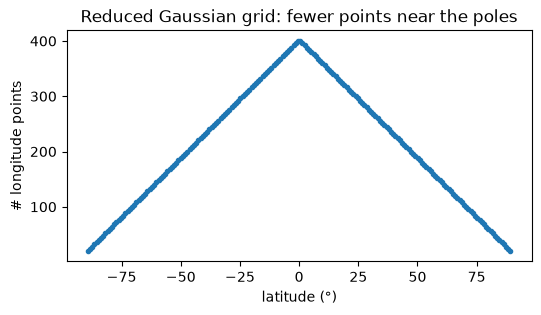

In [4]:
lat = ds.latitudes   # (n_gridpoints,)
lon = ds.longitudes  # (n_gridpoints,)
print("latitudes :", lat.shape, f"[{lat.min():.2f}, {lat.max():.2f}]")
print("longitudes:", lon.shape, f"[{lon.min():.2f}, {lon.max():.2f}]")
print("distinct latitude rings :", len(np.unique(np.round(lat, 3))))

# Number of longitude points per latitude ring shrinks toward the poles:
rings, counts = np.unique(np.round(lat, 3), return_counts=True)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(rings, counts, ".-")
ax.set_xlabel("latitude (°)"); ax.set_ylabel("# longitude points")
ax.set_title("Reduced Gaussian grid: fewer points near the poles")
plt.show()

### Read and plot a weather field

Indexing `ds[t]` returns all variables for time step `t` with shape
`(variable, ensemble, grid_point)`. We pick a variable by its index and squeeze away the
(size-1) ensemble axis to get a flat field over the grid points.

In [5]:
import datetime

def index_for_date(ds, when):
    """Return the time index whose date is closest to `when` (a datetime)."""
    dates = np.array(ds.dates, dtype="datetime64[s]")
    target = np.datetime64(when)
    return int(np.argmin(np.abs(dates - target)))

t_idx = index_for_date(ds, datetime.datetime(2000, 7, 1, 12))
print("using time index", t_idx, "=", ds.dates[t_idx])

var = "2t"                                   # 2 m air temperature
v_idx = ds.name_to_index[var]
field = ds[t_idx][v_idx, 0, :]               # -> (n_gridpoints,)
print(f"{var} field: shape={field.shape}, "
      f"min={np.nanmin(field):.1f} K, max={np.nanmax(field):.1f} K")

using time index 31410 = 2000-07-01T12:00:00
2t field: shape=(40320,), min=203.7 K, max=324.7 K


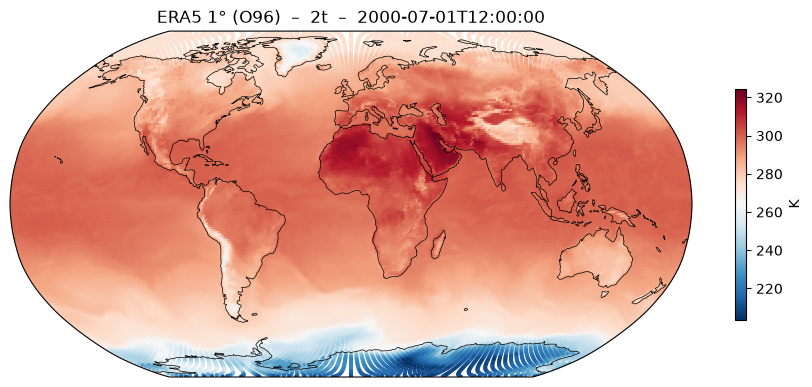

In [6]:
import cartopy.crs as ccrs

def plot_on_grid(lon, lat, values, title, cmap="RdBu_r", units="", s=4):
    """Scatter-plot an unstructured field on a global map."""
    fig = plt.figure(figsize=(11, 5))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.coastlines(linewidth=0.5)
    ax.set_global()
    sc = ax.scatter(lon, lat, c=values, s=s, cmap=cmap,
                    transform=ccrs.PlateCarree())
    plt.colorbar(sc, ax=ax, shrink=0.6, label=units)
    ax.set_title(title)
    plt.show()

plot_on_grid(lon, lat, field,
             f"ERA5 1° (O96)  –  {var}  –  {ds.dates[t_idx]}",
             cmap="RdBu_r", units="K")


### Normalization — why and how

Neural networks train best when every input variable has a similar, moderate scale.
Temperatures are ~290 K, pressures ~100 000 Pa, humidities ~0.01 kg/kg — wildly different
magnitudes. We fix this by **standardizing** each variable to roughly zero mean and unit
variance:

$$\tilde{x} = \frac{x - \mu}{\sigma},$$

where $\mu$ and $\sigma$ are the long-term mean and standard deviation of that variable.
Anemoi ships these precomputed **statistics** with the dataset, so we do not have to
estimate them ourselves.

2t: mean=288.06 K, stdev=15.52 K


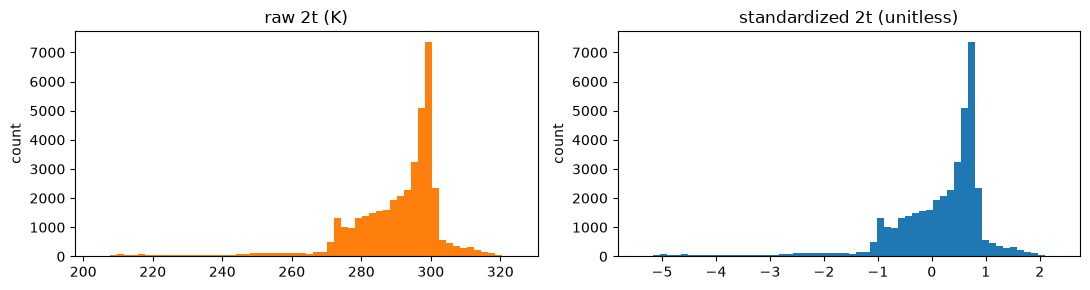

standardized mean/std: 0.11406114764397678 0.9793461849174787


In [7]:
stats = ds.statistics
mu = stats["mean"][v_idx]
sigma = stats["stdev"][v_idx]
print(f"{var}: mean={mu:.2f} K, stdev={sigma:.2f} K")

field_norm = (field - mu) / sigma

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(field, bins=60, color="tab:orange")
axes[0].set_title(f"raw {var} (K)")
axes[1].hist(field_norm, bins=60, color="tab:blue")
axes[1].set_title(f"standardized {var} (unitless)")
for a in axes:
    a.set_ylabel("count")
plt.tight_layout(); plt.show()
print("standardized mean/std:", float(field_norm.mean()), float(field_norm.std()))

## 🧪 Your turn

1. **Another variable.** Plot `msl` (mean sea-level pressure) or `z_500` (geopotential at
   500&nbsp;hPa) for a winter date (e.g. 2000-01-15). Do the patterns look physically
   reasonable? *Hint:* geopotential troughs/ridges are the mid-latitude weather systems.
2. **Seasonality.** Pick `2t` and compare a January field with a July field. Where is the
   seasonal contrast largest — land or ocean? Why?
3. **Statistics.** For three variables of your choice, print `mean`, `stdev`, `minimum`,
   `maximum` from `ds.statistics`. Which variable has the largest relative spread
   (`stdev / |mean|`)?
4. **Grid intuition.** Roughly how many grid points would a *regular* 0.25° global grid
   have (`720 × 1440`)? Compare that to the 40&nbsp;320 points of the O96 grid — by what
   factor are we “upsampling” when we downscale? *(This number matters in notebook 2.)*

## Recap & what’s next

You now know the vocabulary (**encoder → latent → decoder**), the shape of
the WeatherGenerator, and how to open and plot the ERA5 data with **anemoi**.

➡️ **Notebook 2 — `02_downscaling_baseline_bilinear.ipynb`**: we build the target 0.25°
grid and a **bilinear interpolation baseline**, then measure its error. That baseline is
the number the learned WeatherGenerator downscaling will have to beat.
